<h1> Churn Prediction & Customer Segmentation using Dunnhumby Dataset </h1>


# 1. Problem Statement

<p>
<b>Retail Customer Churn Prediction & Segmentation </b>

Retailers generate massive transactional data but struggle to proactively identify customers at risk of churn. Losing engaged customers directly impacts long-term revenue and marketing efficiency.

This project aims to:
<ul>  <b>  
<li>Segment customers based on purchasing behavior</li>

<li>Predict customer churn risk using transaction-level data</li>

<li>Identify key behavioral drivers influencing churn</li>

<li>Provide actionable insights for targeted retention strategies</li><br>
      </b>
    </ul>

Using the Dunnhumby "Complete Journey" retail dataset (2.5M+ transactions across ~2,500 households), we build an end-to-end machine learning pipeline to support customer-centric decision making.
              

### Importing Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


### Load Data

In [2]:
transactions = pd.read_csv(r"D:\ML Projects\Dunnhumby_data\transaction_data.csv")
demo = pd.read_csv(r"D:\ML Projects\Dunnhumby_data\hh_demographic.csv")
product = pd.read_csv(r"D:\ML Projects\Dunnhumby_data\product.csv")

# 2. Data Overview

In [3]:
transactions.shape

(2595732, 12)

In [4]:
demo.shape

(801, 8)

In [5]:
product.shape

(92353, 7)

In [6]:
transactions.columns

Index(['household_key', 'BASKET_ID', 'DAY', 'PRODUCT_ID', 'QUANTITY',
       'SALES_VALUE', 'STORE_ID', 'RETAIL_DISC', 'TRANS_TIME', 'WEEK_NO',
       'COUPON_DISC', 'COUPON_MATCH_DISC'],
      dtype='object')

In [7]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [8]:
demo.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [9]:
product.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


### Convert Day into daytime

In [10]:
transactions['DAY'] = pd.to_datetime(transactions['DAY'], unit='D')

In [11]:
transactions.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1970-01-02,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1970-01-02,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1970-01-02,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1970-01-02,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1970-01-02,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [12]:
latest_date = transactions['DAY'].max()

In [13]:
print(latest_date)

1971-12-13 00:00:00


In [14]:
customer_df = transactions.groupby('household_key').agg({
    'DAY': ['max', 'min', 'count'],
    'SALES_VALUE':['sum','mean'],
    'QUANTITY':'sum'
})

### For each customer:
<ul>
<li>last purchase date
</li>
<li>first purchase date
</li>
<li>number of transactions
</li>
<li>total money spent
</li>
<li>average spend per transaction
</li>
    <li>total quantity bought</li>

In [15]:
customer_df.columns

MultiIndex([(        'DAY',   'max'),
            (        'DAY',   'min'),
            (        'DAY', 'count'),
            ('SALES_VALUE',   'sum'),
            ('SALES_VALUE',  'mean'),
            (   'QUANTITY',   'sum')],
           )

In [16]:
customer_df.columns = [
    'last_purchase',
    'first_purchase',
    'total_transactions',
    'total_spend',
    'avg_spend',
    'total_quantity'
]


In [17]:
customer_df = customer_df.reset_index()

### Creating Recency Feature

In [18]:
customer_df['recency'] = (
        latest_date - customer_df['last_purchase']
).dt.days

### Creating Frequency Feature

In [19]:
customer_df['frequency'] = (customer_df['total_transactions'] )

### Creating Monetary Feature

In [20]:
customer_df['monetary'] = (customer_df['total_spend'])

In [21]:
customer_df.head()

,household_key,last_purchase,first_purchase,total_transactions,total_spend,avg_spend,total_quantity,recency,frequency,monetary
0,1,1971-12-08,1970-02-21,1727,4330.16,2.507331,1997,5,1727,4330.16
1,2,1971-10-31,1970-04-14,714,1954.34,2.737171,834,43,714,1954.34
2,3,1971-12-05,1970-04-24,922,2653.21,2.877668,8540,8,922,2653.21
3,4,1971-09-20,1970-04-15,301,1200.11,3.987076,382,84,301,1200.11
4,5,1971-12-05,1970-03-27,222,779.06,3.509279,245,8,222,779.06


## CUSTOMER SEGMENTATION (K-Means)

In [22]:
rfm = customer_df[['recency','frequency','monetary']]
rfm.head()

,recency,frequency,monetary
0,5,1727,4330.16
1,43,714,1954.34
2,8,922,2653.21
3,84,301,1200.11
4,8,222,779.06


### Scaling the data
<p> Clustering is a distance based algorithm, so if we dont scale the features like monetary and recency then monetary will clearly dominate the frequency feature.

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [24]:
rfm_scaled

array([[-0.32772577,  0.68946733,  0.33066218],
       [ 0.27758089, -0.32465072, -0.37888598],
       [-0.2799384 , -0.11642115, -0.17016566],
       ...,
       [-0.39144226, -0.17949069, -0.18557919],
       [-0.37551314,  0.12784815,  0.05109515],
       [-0.35958402,  0.4652201 ,  0.67590621]], shape=(2500, 3))

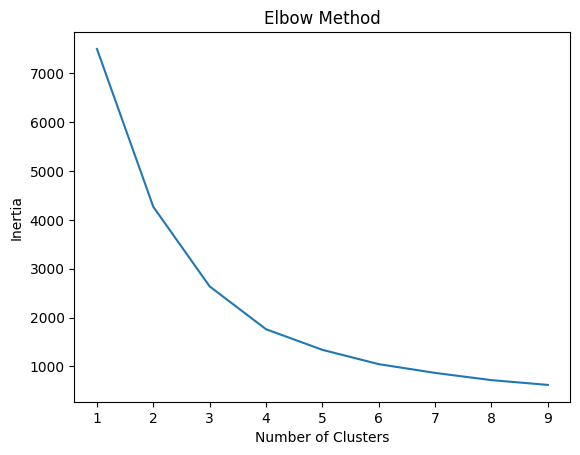

In [25]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Graph Observation
<p>
    <ul>
<li>Huge drop from k = 1 → 2 </li>
<li>Big drop from 2 → 3 </li>
<li>Noticeable drop from 3 → 4 </li>
<li>After 4, the curve starts flattening </li>
        <li>After k = 4, improvement becomes small and gradual. </li>
</ul>

### Where Is The Elbow?
<b>The elbow is around k = 4</b>

### Why?

Because:<br>
Before 4 → steep decrease (big improvement)<br>
After 4 → diminishing returns (small improvement)<br>
That bending point = optimal clusters.<br>
k = 4 (Best Choice)
Now we can identify:
1.	High Value Customers
2.	Loyal Regular Customers
3.	At Risk Customers
4.	Low Value / Inactive Customers


In [26]:
kmeans = KMeans(n_clusters = 4,random_state=42)
customer_df['Segmentation'] = kmeans.fit_predict(rfm_scaled)

In [27]:
customer_df.columns


Index(['household_key', 'last_purchase', 'first_purchase',
       'total_transactions', 'total_spend', 'avg_spend', 'total_quantity',
       'recency', 'frequency', 'monetary', 'Segmentation'],
      dtype='object')

In [28]:
customer_df.groupby('Segmentation')[['recency','frequency','monetary']].mean()

,recency,frequency,monetary
Segmentation,,,
0,22.809917,491.612842,1460.302695
1,3.089286,3704.136905,12374.822976
2,324.169014,179.042254,573.990423
3,6.569767,1725.898256,5291.690930


In [29]:

segment_map = {
    0: "Regular",
    1: "Elite",
    2: "Churned",
    3: "Loyal High Value"
}

customer_df['segment_label'] = customer_df['Segmentation'].map(segment_map)


In [30]:
customer_df.columns

Index(['household_key', 'last_purchase', 'first_purchase',
       'total_transactions', 'total_spend', 'avg_spend', 'total_quantity',
       'recency', 'frequency', 'monetary', 'Segmentation', 'segment_label'],
      dtype='object')

In [31]:
customer_df['segment_label'].value_counts()

segment_label
Regular             1573
Loyal High Value     688
Elite                168
Churned               71
Name: count, dtype: int64

## CHURN LABEL CREATION

Customer is churned if:<br>
recency > 90 days<br>
OR<br>
recency > 120 days<br>

In [32]:
customer_df['churn'] = np.where(customer_df['recency'] > 90, 1, 0)


In [33]:
customer_df['churn'].value_counts()

churn
0    2329
1     171
Name: count, dtype: int64

# 3. Feature Engineering Summary

Customer-level features were engineered from transaction-level data to capture behavioral patterns influencing churn.

<b> 1. Aggregation to Customer Level

Transaction data was grouped by household_key to create customer-level metrics.

<b> 2. RFM-Based Features

RFM (Recency, Frequency, Monetary) framework was used as core behavioral modeling foundation.

<b> Recency</b><br>
Number of days since the customer’s last transaction.
(Used for churn labeling only to avoid leakage in model training)

<b> Frequency</b> <br>
Total number of transactions per customer.
Captures engagement intensity.

<b> Monetary </b><br>
Total spending across all transactions.
Represents customer lifetime value proxy.

<b> 3. Additional Behavioral Features

To enhance predictive capability beyond RFM:

Total Quantity Purchased
Total units bought across all transactions.

Average Spend per Transaction
Monetary value divided by transaction count.

These features capture purchasing depth and basket behavior.

<b> 4. Churn Label Creation

Churn was defined as:

Customer with no purchase activity in the last 90 days.

Binary target variable:

1 → Churned

0 → Active

Recency was excluded from model features to prevent target leakage.

<b> 5. Data Scaling

StandardScaler was applied to numerical features before model training to ensure comparable feature magnitudes for logistic regression.

# 4. Model Training

## Churn Prediction Model
   <p>
    <ol>
    <li>Prepare features</li>
    <li>Split data</li>
    <li>Handle imbalance</li>
    <li>Train model</li>
    <li>Evaluate properly (NOT accuracy only)</li>
    </ol>

### Step-1 Prepare Features

In [34]:
features = customer_df[['frequency','monetary','total_quantity','avg_spend']]
target = customer_df['churn']

### Step-2 Train-Test split

In [35]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    features,
    target,
    test_size = 0.2,
    random_state=42,
    stratify = target # very important for imbalanced data
)

### Step-3 Scale Features

In [36]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Step-4 Train First Model (Logistic Regression)

In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Step-5 Make Predictions


In [39]:
y_pred = model.predict(x_test_scaled)
y_prob = model.predict_proba(x_test_scaled)[:,1]

### Step-6 Evaluate 

In [40]:
from sklearn.metrics import classification_report, roc_auc_score

In [41]:

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       466
           1       0.00      0.00      0.00        34

    accuracy                           0.93       500
   macro avg       0.47      0.50      0.48       500
weighted avg       0.87      0.93      0.90       500

ROC-AUC: 0.8153875284019187


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

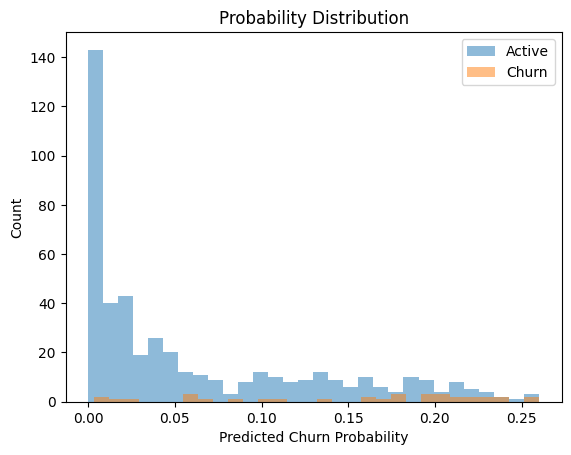

In [42]:
import matplotlib.pyplot as plt

plt.hist(y_prob[y_test == 0], bins=30, alpha=0.5, label='Active')
plt.hist(y_prob[y_test == 1], bins=30, alpha=0.5, label='Churn')
plt.legend()
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Count")
plt.title("Probability Distribution")
plt.show()


## Random Forest
<b>Logistic Regression is linear. since Retail behavior is often nonlinear so we will experiment with Random Forest too.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(x_train, y_train)

y_prob_rf = rf_model.predict_proba(x_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


ROC-AUC: 0.7511676344357485


In [44]:
y_pred_rf = (y_prob_rf > 0.1).astype(int)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.97      0.83      0.89       466
           1       0.21      0.62      0.31        34

    accuracy                           0.82       500
   macro avg       0.59      0.72      0.60       500
weighted avg       0.92      0.82      0.85       500



# 5. Evaluation

### Random Forest             Vs.     Logistic Regression
<p>ROC-AUC = 0.75 &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp  ROC-AUC = 0.81 <br>
Recall (0.1 threshold) = 0.62 &nbsp  Recall (0.1 threshold) = 0.74 <br> 
Accuracy = 82% &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp &nbsp Accuracy=73%<br>

</p>

### Which Model Should Choose?

as of now:<br>
<b>Logistic Regression is better.</b> <br>
Higher ROC-AUC.<br>
Better recall.<br>
Simpler.<br>
More interpretable.<br>

# 6. Threshold Optimization

In [45]:
y_pred_01 = (y_prob > 0.1).astype(int)
print(classification_report(y_test, y_pred_01))


              precision    recall  f1-score   support

           0       0.97      0.73      0.83       466
           1       0.16      0.74      0.27        34

    accuracy                           0.73       500
   macro avg       0.57      0.73      0.55       500
weighted avg       0.92      0.73      0.79       500



### Threshold = 0.1
<b>Churn (class 1):</b>
<p>
Recall = 0.74 <br>
Precision = 0.16 <br>
Accuracy = 73% <br>

Meaning:<br>
Out of 34 churned customers and this threshold is catching 74% of them.<br>
But:<br>
Many active customers are falsely flagged as churn.

In [46]:
y_pred_005 = (y_prob > 0.05).astype(int)
print(classification_report(y_test, y_pred_005))


              precision    recall  f1-score   support

           0       0.99      0.62      0.76       466
           1       0.15      0.88      0.25        34

    accuracy                           0.64       500
   macro avg       0.57      0.75      0.51       500
weighted avg       0.93      0.64      0.73       500



### Threshold = 0.05
<b>Churn (class 1):</b><br>

Recall = 0.88<br>
Precision = 0.15<br>
Accuracy = 64%<br>
Meaning:<br>
Now you catch almost 90% of churners.<br>
But <br>
false positives increase more.

# 7. Feature Importance

In [47]:
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': model.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False)


,Feature,Coefficient
2,total_quantity,0.417067
3,avg_spend,-0.088443
1,monetary,-1.392134
0,frequency,-1.743892


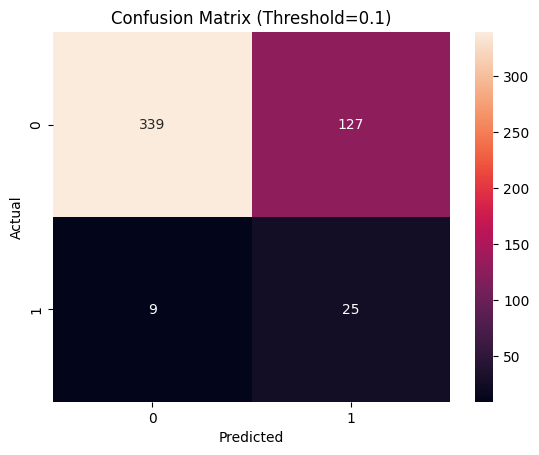

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_01)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold=0.1)")
plt.show()


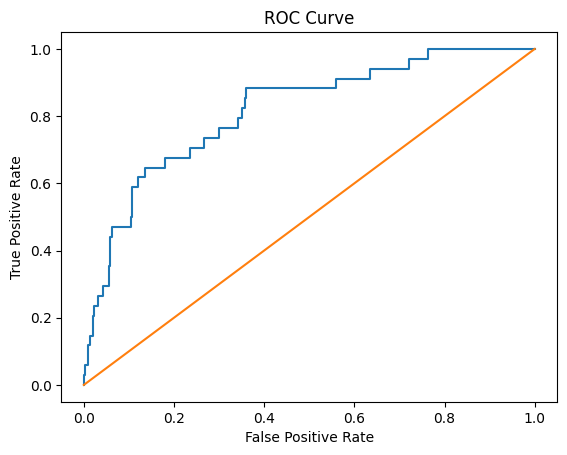

In [51]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [52]:
thresholds_to_test = [0.5, 0.1, 0.05]

results = []

for t in thresholds_to_test:
    y_pred_temp = (y_prob > t).astype(int)
    from sklearn.metrics import recall_score, precision_score, accuracy_score
    
    results.append({
        "Threshold": t,
        "Recall_Churn": recall_score(y_test, y_pred_temp),
        "Precision_Churn": precision_score(y_test, y_pred_temp),
        "Accuracy": accuracy_score(y_test, y_pred_temp)
    })

pd.DataFrame(results)


C:\Users\hp\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Threshold,Recall_Churn,Precision_Churn,Accuracy
0,0.50,0.000000,0.000000,0.932
1,0.10,0.735294,0.164474,0.728
2,0.05,0.882353,0.145631,0.640


# 8. Business Insights
<ul>
    <li>Frequency is strongest driver of retention.</li>
<li>High total spending reduces churn probability.</li>
<li>Model ROC-AUC of 0.81 indicates strong ranking ability.</li>
<li>Lower threshold increases recall at cost of precision.</li>
<li>Retailers can adjust threshold based on campaign budget.</li>
    
</ul>

In [55]:
import joblib
import numpy as np

model = joblib.load(r"D:\ML Projects\Dunnhumby_Project\models\logistic_model.pkl")
scaler = joblib.load(r"D:\ML Projects\Dunnhumby_Project\models\scaler.pkl")

def predict_churn(frequency, monetary, total_quantity, avg_spend):
    data = np.array([[frequency, monetary, total_quantity, avg_spend]])
    data_scaled = scaler.transform(data)
    prob = model.predict_proba(data_scaled)[0][1]
    return prob

In [56]:
import joblib

joblib.dump(model, r"D:\ML Projects\Dunnhumby_Project\models\logistic_model.pkl")
joblib.dump(scaler, r"D:\ML Projects\Dunnhumby_Project\models\scaler.pkl")

['D:\\ML Projects\\Dunnhumby_Project\\models\\scaler.pkl']